# Configuración de carpeta de datos

La competencia elegida para este EDA se encuentra en el siguiente [Enlace](https://www.kaggle.com/competitions/cafa-6-protein-function-prediction)

## Si se ejecuta desde Google Colab ejecuta la siguiente celda

In [ ]:
# Montar drive para datos persistentes
from google.colab import drive
drive.mount('/content/drive')
content_path = "/content/drive/MyDrive/data/proteinas"

Mounted at /content/drive


## Si se ejecuta localmente ejecuta la siguiente celda

In [7]:
content_path = "cafa-6-protein-function-prediction"

### Cargar datos

In [8]:
import pandas as pd

df = pd.read_csv(f'{content_path}/IA.tsv', sep="\t")
print(df.head())

   GO:0000001       0.0
0  GO:0000002  2.849666
1  GO:0000011  0.137504
2  GO:0000012  6.038630
3  GO:0000017  0.514573
4  GO:0000018  1.879637


In [4]:
!pwd
!ls
!sudo apt-get install tree
!tree cafa-6-protein-function-prediction

"pwd" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
Sudo está deshabilitado en este equipo. Para habilitarlo, vaya a ]8;;ms-settings:developers\Página Configuración del desarrollador]8;;\ en la aplicación Configuración


Listado de rutas de carpetas para el volumen Stuff
El n�mero de serie del volumen es 5875-88B6
S:\UAM\25-O\APRENDIZAJE MAQUINAL\PROYECTO\COMPETENCIAS\PROTEINAS\CAFA-6-PROTEIN-FUNCTION-PREDICTION
+---Test
+---Train


In [5]:
!pip install biopython
!pip install matplotlib seaborn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO

  Obtaining dependency information for biopython from https://files.pythonhosted.org/packages/a9/13/00db03b01e54070d5b0ec9c71eef86e61afa733d9af76e5b9b09f5dc9165/biopython-1.86-cp312-cp312-win_amd64.whl.metadata
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
    --------------------------------------- 0.0/2.7 MB 653.6 kB/s eta 0:00:05
   - -------------------------------------- 0.1/2.7 MB 1.1 MB/s eta 0:00:03
   --- ------------------------------------ 0.3/2.7 MB 1.7 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.7 MB 4.1 MB/s eta 0:00:01
   --------------------- ------------------ 1.5/2.7 MB 6.3 MB/s eta 0:00:01
   ---------------------------------- ----- 2.3/2.7 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 8.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/31/3c/80816f027b3a4a28cd2a0a6ef7f89a2db22310e945cd886ec25bfb399221/matplotlib-3.10.7-cp312-cp312-win_amd64.whl.metadata
  Using cached matplotlib-3.10.7-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/19/e8/6026ed58a64563186a9ee3f29f41261fd1828f527dd93d33b60feca63352/contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b4


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
#Configuracion visual de sns
sns.set_style("whitegrid")

In [9]:
#Cargamos los datos

terms=pd.read_csv(f'{content_path}/Train/train_terms.tsv',sep='\t')
taxonomy=pd.read_csv(f'{content_path}/Train/train_taxonomy.tsv',sep='\t', header=None, names=['EntryID', 'taxonomyID'])
ia_weights=pd.read_csv(f'{content_path}/IA.tsv', sep='\t', names=['term', 'weight'])

Analisis de la variable Terms (Variable objetivo)

In [ ]:
print(terms.head())
num_proteins=terms['EntryID'].nunique()
num_terms=terms['term'].nunique()
print(f'Numero de proteinas unicas: {num_proteins}')
print(f'Numero de terminos GO unicos: {num_terms}')

  EntryID        term aspect
0  Q5W0B1  GO:0000785      C
1  Q5W0B1  GO:0004842      F
2  Q5W0B1  GO:0051865      P
3  Q5W0B1  GO:0006275      P
4  Q5W0B1  GO:0006513      P
Numero de proteinas unicas: 82404
Numero de terminos GO unicos: 26125


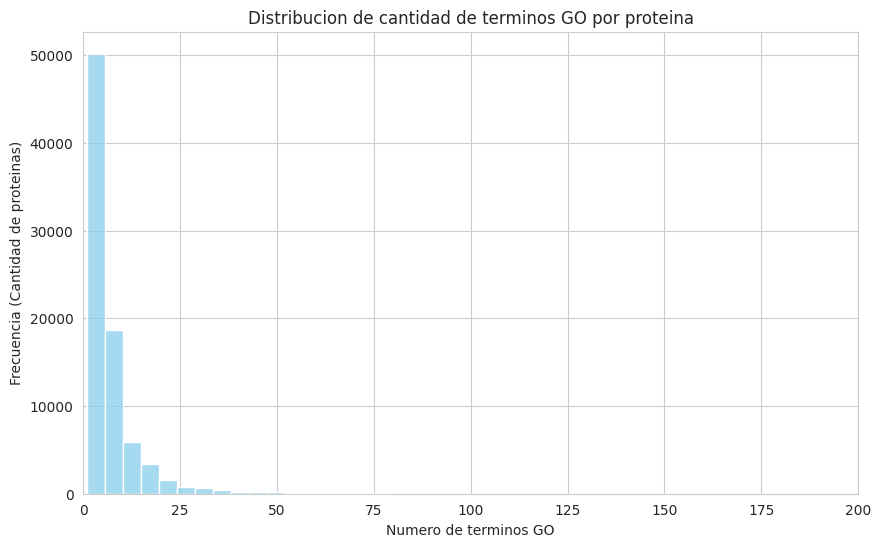

In [ ]:
#Histograma de terminos de las prooteinas
term_counts=terms.groupby('EntryID')['term'].count()
plt.figure(figsize=(10,6))
sns.histplot(term_counts, bins=50, kde=False, color='skyblue')
plt.title('Distribucion de cantidad de terminos GO por proteina')
plt.xlabel('Numero de terminos GO')
plt.ylabel('Frecuencia (Cantidad de proteinas)')
plt.xlim(0,200)
plt.show()

In [10]:
# Analisis de las secuencias
lenghts=[]
ids=[]
for record in SeqIO.parse(f"{content_path}/Train/train_sequences.fasta", "fasta"):
  lenghts.append(len(record.seq))
  ids.append(record.id)

df_seq=pd.DataFrame({'EntryID':ids, 'Length':lenghts})
print("\nEstadisticas base de la longitud de las secuencias")
print(df_seq['Length'].describe())



Estadisticas base de la longitud de las secuencias
count    82404.000000
mean       525.788287
std        521.574869
min          3.000000
25%        250.000000
50%        409.000000
75%        630.000000
max      35213.000000
Name: Length, dtype: float64


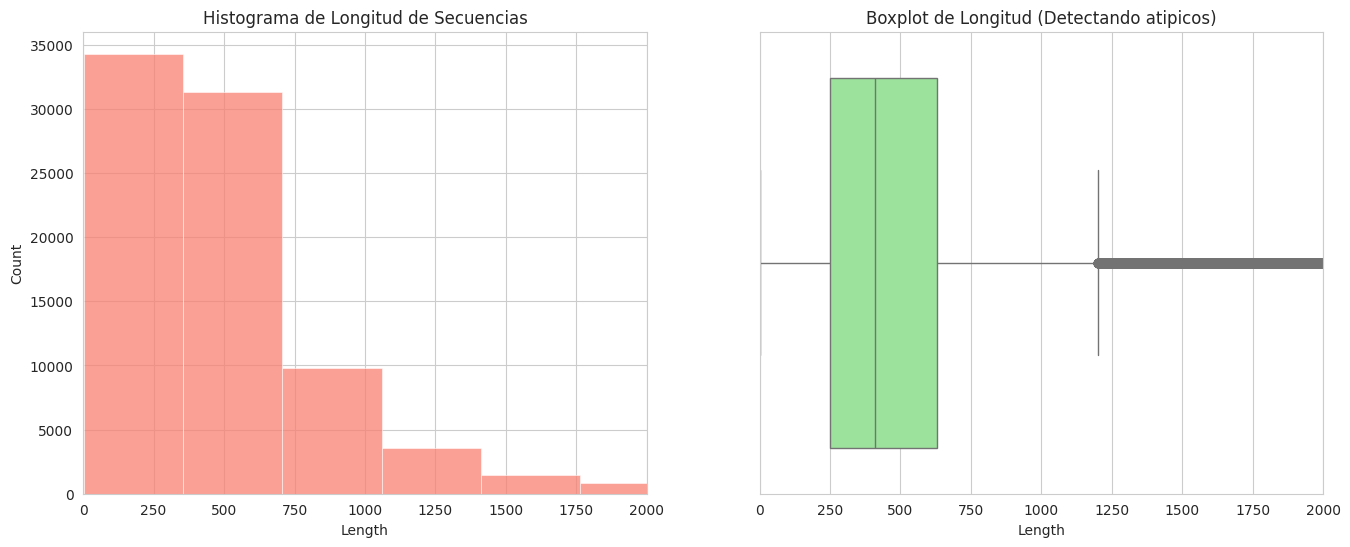

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_seq['Length'], bins=100, ax=ax[0], color='salmon')
ax[0].set_title('Histograma de Longitud de Secuencias')
ax[0].set_xlim(0, 2000)

sns.boxplot(x=df_seq['Length'], ax=ax[1], color='lightgreen')
ax[1].set_title('Boxplot de Longitud (Detectando atipicos)')
ax[1].set_xlim(0, 2000)

plt.show()

      EntryID  taxonomyID
0  A0A0C5B5G6        9606
1      A0JNW5        9606
2      A0JP26        9606
3      A0PK11        9606
4      A1A4S6        9606


/tmp/ipython-input-2771354783.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_species.index.astype(str), y=top_species.values, palette="viridis")


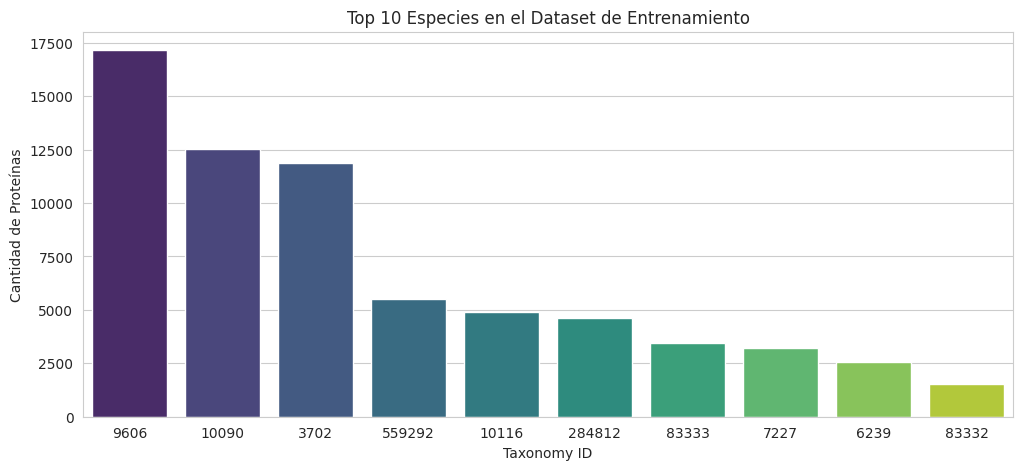

In [ ]:
# Analisis sobre las relaciones taxonomicas
print(taxonomy.head())
top_species = taxonomy['taxonomyID'].value_counts().head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_species.index.astype(str), y=top_species.values, palette="viridis")
plt.title('Top 10 Especies en el Dataset de Entrenamiento')
plt.xlabel('Taxonomy ID')
plt.ylabel('Cantidad de Proteínas')
plt.show()

Para manejar el archivo .obo necesitamos una libreria especial llamda obonet

In [13]:
!pip install obonet networkx

  Obtaining dependency information for obonet from https://files.pythonhosted.org/packages/a3/86/ae23b7033126c05b7a75b06796b3627a8dc866df2de2f4a30b8796863675/obonet-1.1.1-py3-none-any.whl.metadata
  Obtaining dependency information for networkx from https://files.pythonhosted.org/packages/07/c7/d64168da60332c17d24c0d2f08bdf3987e8d1ae9d84b5bbd0eec2eb26a55/networkx-3.6-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
    --------------------------------------- 0.0/2.1 MB 1.4 MB/s eta 0:00:02
   -- ------------------------------------- 0.1/2.1 MB 1.7 MB/s eta 0:00:02
   ------ --------------------------------- 0.3/2.1 MB 2.6 MB/s eta 0:00:01
   ------------ --------------------------- 0.6/2.1 MB 3.6 MB/s eta 0:00:01
   -------------------- ------------------- 1.1/2.1 MB 5.1 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------  2.0/2.1 MB 6.8 MB/s eta 0:00:01
   


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import networkx as nx
import obonet

obo_file=content_path+'/Train/go-basic.obo'
graph=obonet.read_obo(obo_file)

print("\nEstadistica del grafo")
print(f'Numero de nodos: {len(graph)}')
print(f'Numero de aristas: {graph.number_of_edges()}')
print(f"Grafo dirigido?: {nx.is_directed_acyclic_graph(graph)}")



Estadistica del grafo
Numero de nodos: 40122
Numero de aristas: 77229
Grafo dirigido?: True


In [ ]:
namespace=[]
for node, data in graph.nodes(data=True):
  namespace.append(data.get('namespace', 'unknown'))

df_ns=pd.Series(namespace)
counts=df_ns.value_counts()
print(counts)

biological_process    25950
molecular_function    10131
cellular_component     4041
Name: count, dtype: int64


/tmp/ipython-input-3402945892.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts.values, palette="rocket")


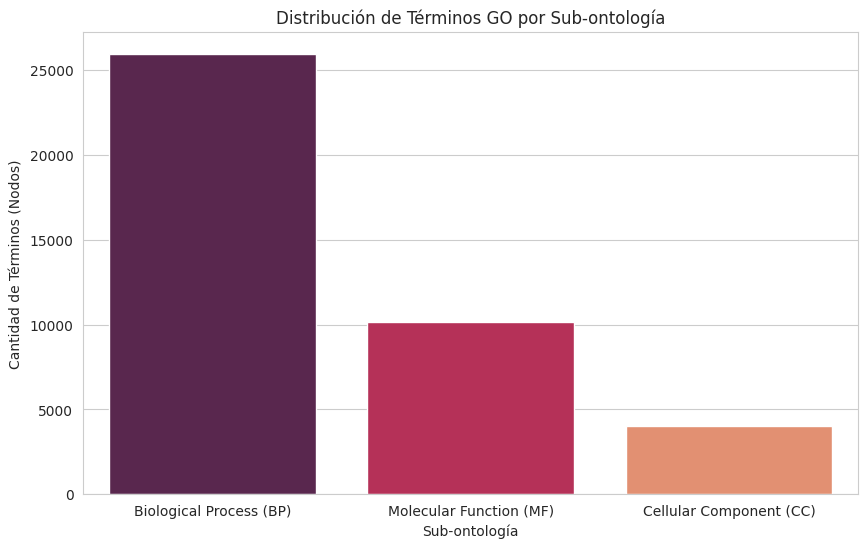

In [ ]:
#Visualizar
name_map={
    'biological_process': 'Biological Process (BP)',
    'molecular_function': 'Molecular Function (MF)',
    'cellular_component': 'Cellular Component (CC)'
}
labels=[name_map.get(x,x) for x in counts.index]
plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=counts.values, palette="rocket")
plt.title('Distribución de Términos GO por Sub-ontología')
plt.ylabel('Cantidad de Términos (Nodos)')
plt.xlabel('Sub-ontología')
plt.show()


In [ ]:
#Ejemplo de un nodo
example_node=list(graph.nodes())[0]
print(graph.nodes[example_node])

{'name': 'mitochondrion inheritance', 'namespace': 'biological_process', 'def': '"The distribution of mitochondria, including the mitochondrial genome, into daughter cells after mitosis or meiosis, mediated by interactions between mitochondria and the cytoskeleton." [GOC:mcc, PMID:10873824, PMID:11389764]', 'synonym': ['"mitochondrial inheritance" EXACT []'], 'is_a': ['GO:0048308', 'GO:0048311']}
